<a href="https://colab.research.google.com/github/roksanakanicka/image_classification/blob/main/DL_projekt_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image Classification: Men vs Women - CNN vs EfficientNet-B0

Binary image classification on a Kaggle dataset (1668 images, classes men/women).Comparison of two approaches: a CNN trained from scratch and EfficientNet-B0 with transfer learning

In [1]:
import os
import json
import hashlib
from collections import Counter
from getpass import getpass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset, random_split
import torch.nn as nn
from torchsummary import summary

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support
)

## Data

In [2]:
kaggle_username = input("Kaggle username: ")
kaggle_key = getpass("Kaggle API key: ")

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump({"username": kaggle_username, "key": kaggle_key}, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

Kaggle username: hubertwiniewski
Kaggle API key: ··········


In [3]:
!pip install kaggle -q
!kaggle datasets download -d snmahsa/human-images-dataset-men-and-women
!unzip -q -o human-images-dataset-men-and-women.zip -d dataset

Dataset URL: https://www.kaggle.com/datasets/snmahsa/human-images-dataset-men-and-women
License(s): MIT
100% 692M/692M [00:35<00:00, 20.4MB/s]



In [4]:
DATA_DIR = "dataset/gender_dataset"
IMG_SIZE = 224
BATCH_SIZE = 32
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

In [5]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [6]:
base_dataset = datasets.ImageFolder(root=DATA_DIR)
print("Classes:", base_dataset.classes)
print("Total images:", len(base_dataset))

total = len(base_dataset)
test_size = int(total * TEST_SPLIT)
val_size = int(total * VAL_SPLIT)
train_size = total - val_size - test_size

train_idx, val_idx, test_idx = random_split(
    range(total), [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)
train_idx, val_idx, test_idx = train_idx.indices, val_idx.indices, test_idx.indices

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

Classes: ['men', 'women']
Total images: 1668
Train: 1168 | Val: 250 | Test: 250


## Data validation

Checking class balance, data leakage between splits, and duplicates.

In [7]:
labels_all = [base_dataset.targets[i] for i in range(total)]
class_counts = Counter(labels_all)
for class_idx, count in sorted(class_counts.items()):
    print(f"{base_dataset.classes[class_idx]}: {count} ({count/total*100:.1f}%)")

imbalance_ratio = max(class_counts.values()) / min(class_counts.values())
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

men: 833 (49.9%)
women: 835 (50.1%)
Imbalance ratio: 1.00


In [8]:
train_idx_set, val_idx_set, test_idx_set = set(train_idx), set(val_idx), set(test_idx)
assert not (train_idx_set & val_idx_set)
assert not (train_idx_set & test_idx_set)

In [9]:
def file_md5(path, chunk_size=8192):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

all_paths = [s[0] for s in base_dataset.samples]
path_to_idx = {s[0]: i for i, s in enumerate(base_dataset.samples)}

hashes = {}
for path in all_paths:
    hashes.setdefault(file_md5(path), []).append(path)

duplicate_groups = [paths for paths in hashes.values() if len(paths) > 1]
print(f"Duplicate groups: {len(duplicate_groups)}")

Duplicate groups: 17


In [10]:
# Deleting duplicates
indices_to_remove = set()
for group in duplicate_groups:
    by_split = {"train": [], "val": [], "test": []}
    for path in group:
        idx = path_to_idx[path]
        if idx in train_idx_set:
            by_split["train"].append(idx)
        elif idx in val_idx_set:
            by_split["val"].append(idx)
        elif idx in test_idx_set:
            by_split["test"].append(idx)
    if by_split["train"] and (by_split["val"] or by_split["test"]):
        indices_to_remove.update(by_split["train"])

train_idx = [i for i in train_idx if i not in indices_to_remove]
print(f"Deleted {len(indices_to_remove)} images")
print(f"Train after: {len(train_idx)}")

Deleted 9 images
Train after: 1159


In [11]:
corrupted = []
modes = Counter()
for path in all_paths:
    try:
        with Image.open(path) as img:
            modes[img.mode] += 1
    except Exception as e:
        corrupted.append(path)

print(f"Corrupted: {len(corrupted)}")
print(f"Color types: {dict(modes)}")

Corrupted: 0
Color types: {'RGB': 1663, 'P': 4, 'RGBA': 1}


## Dataset and DataLoaders

In [12]:
train_dataset_full = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
eval_dataset_full = datasets.ImageFolder(root=DATA_DIR, transform=eval_transform)

train_set = Subset(train_dataset_full, train_idx)
val_set = Subset(eval_dataset_full, val_idx)
test_set = Subset(eval_dataset_full, test_idx)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}")

Batches: train=37, val=8, test=8


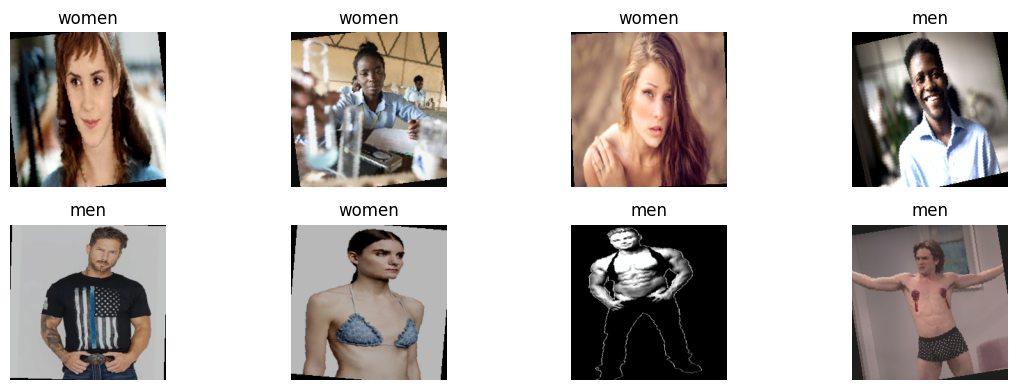

In [13]:
def imshow(tensor, title=None):
    img = tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = np.clip(std * img + mean, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis("off")

images, labels = next(iter(train_loader))
classes = base_dataset.classes

plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow(images[i], title=classes[labels[i]])
plt.tight_layout()
plt.show()

## Models

SimpleCNN trained from scratch (baseline). EfficientNet-B0 - transfer learning, trained in two phases: frozen backbone, then fine-tuning.

In [14]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 2)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def build_efficientnet(num_classes=2, freeze_backbone=True):
    model = models.efficientnet_b0(weights="IMAGENET1K_V1")
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, num_classes)
    )
    return model

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

cnn_model = SimpleCNN().to(device)
eff_model = build_efficientnet(freeze_backbone=True).to(device)

summary(cnn_model, (3, IMG_SIZE, IMG_SIZE))

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 198MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
       BatchNorm2d-2         [-1, 32, 224, 224]              64
              ReLU-3         [-1, 32, 224, 224]               0
         MaxPool2d-4         [-1, 32, 112, 112]               0
            Conv2d-5         [-1, 64, 112, 112]          18,496
       BatchNorm2d-6         [-1, 64, 112, 112]             128
              ReLU-7         [-1, 64, 112, 112]               0
         MaxPool2d-8           [-1, 64, 56, 56]               0
            Conv2d-9          [-1, 128, 56, 56]          73,856
      BatchNorm2d-10          [-1, 128, 56, 56]             256
             ReLU-11          [-1, 128, 56, 56]               0
        MaxPool2d-12          [-1, 128, 28, 28]               0
AdaptiveAvgPool2d-13            [-1, 128, 1, 1]               0
          Flatten-14                  [

## Train

In [16]:
def train_model(model, train_loader, val_loader, epochs, lr, phase_name=""):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=2, factor=0.5
    )

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    print(f"--- {phase_name} ---")

    for epoch in range(epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            correct += outputs.max(1)[1].eq(labels).sum().item()
            total += labels.size(0)
        train_loss /= total
        train_acc = correct / total

        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                correct += outputs.max(1)[1].eq(labels).sum().item()
                total += labels.size(0)
        val_loss /= total
        val_acc = correct / total

        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.1f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.1f}%")

    return history

In [17]:
EPOCHS = 15

cnn_history = train_model(
    cnn_model, train_loader, val_loader,
    epochs=EPOCHS, lr=1e-3, phase_name="Simple CNN"
)

eff_history = train_model(
    eff_model, train_loader, val_loader,
    epochs=10, lr=1e-3, phase_name="EfficientNet - Frozen backbone"
)

for param in eff_model.parameters():
    param.requires_grad = True

eff_history2 = train_model(
    eff_model, train_loader, val_loader,
    epochs=5, lr=1e-4, phase_name="EfficientNet - Fine-tuning"
)

for key in eff_history:
    eff_history[key].extend(eff_history2[key])

--- Simple CNN ---
Epoch 01/15 | Train Loss: 0.6650 | Train Acc: 60.7% | Val Loss: 0.6431 | Val Acc: 66.0%
Epoch 02/15 | Train Loss: 0.6513 | Train Acc: 63.5% | Val Loss: 0.6393 | Val Acc: 65.2%
Epoch 03/15 | Train Loss: 0.6475 | Train Acc: 63.8% | Val Loss: 0.6531 | Val Acc: 62.8%
Epoch 04/15 | Train Loss: 0.6516 | Train Acc: 60.1% | Val Loss: 0.6381 | Val Acc: 62.4%
Epoch 05/15 | Train Loss: 0.6370 | Train Acc: 63.5% | Val Loss: 0.6413 | Val Acc: 68.4%
Epoch 06/15 | Train Loss: 0.6341 | Train Acc: 62.9% | Val Loss: 0.6420 | Val Acc: 66.4%
Epoch 07/15 | Train Loss: 0.6324 | Train Acc: 64.0% | Val Loss: 0.6500 | Val Acc: 66.0%
Epoch 08/15 | Train Loss: 0.6175 | Train Acc: 65.8% | Val Loss: 0.6222 | Val Acc: 67.2%
Epoch 09/15 | Train Loss: 0.6206 | Train Acc: 67.1% | Val Loss: 0.6133 | Val Acc: 71.2%
Epoch 10/15 | Train Loss: 0.6162 | Train Acc: 66.6% | Val Loss: 0.6075 | Val Acc: 70.8%
Epoch 11/15 | Train Loss: 0.6073 | Train Acc: 67.4% | Val Loss: 0.6024 | Val Acc: 70.0%
Epoch 12/15 |

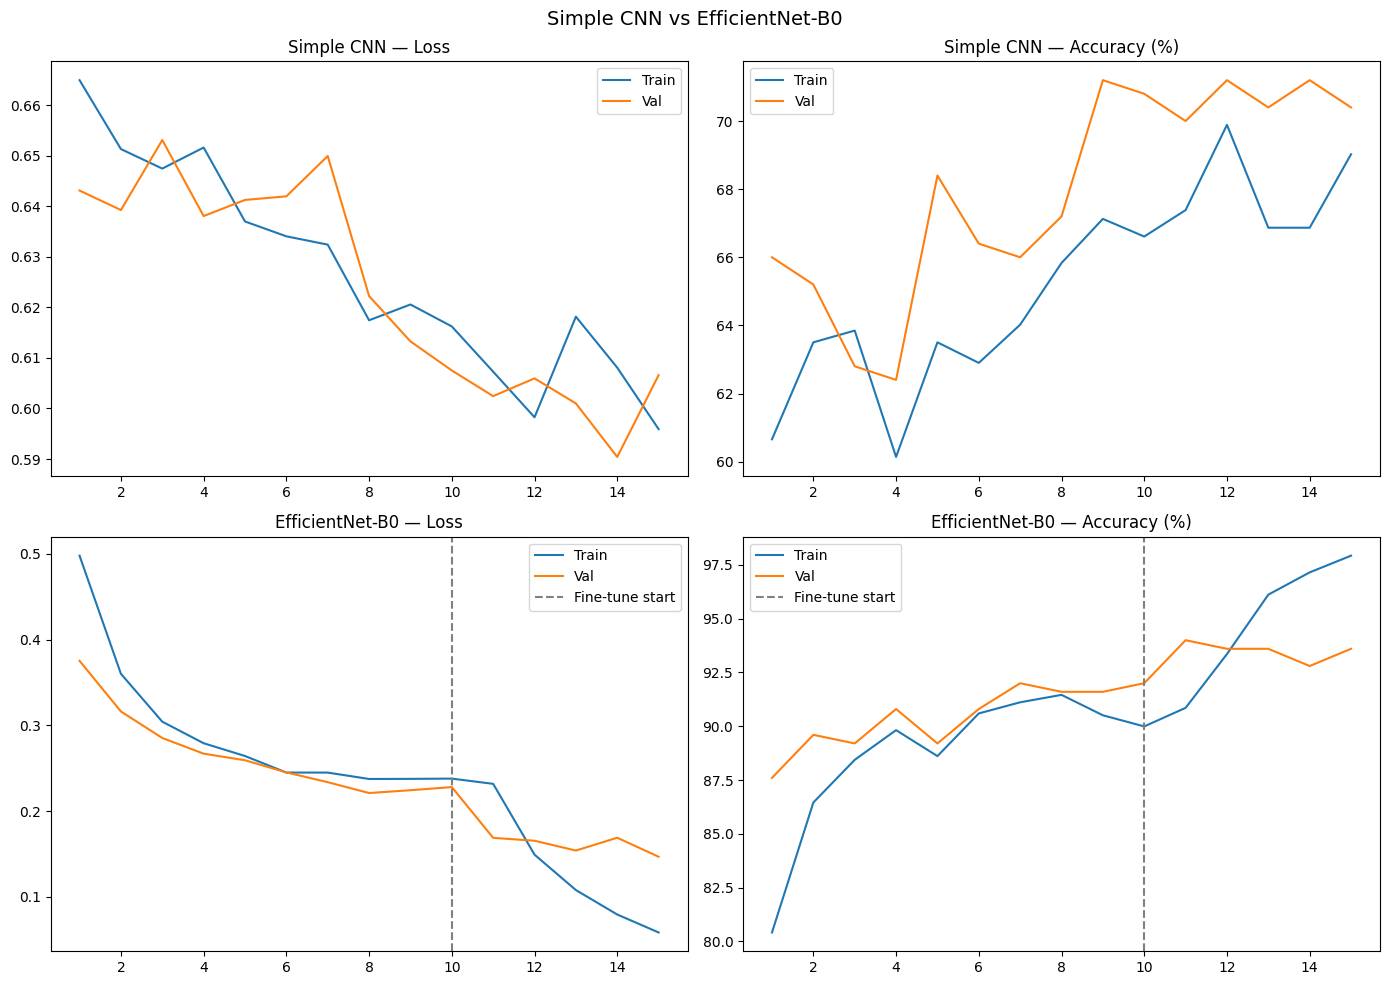

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Simple CNN vs EfficientNet-B0", fontsize=14)

epochs_cnn = range(1, len(cnn_history["train_loss"]) + 1)
epochs_eff = range(1, len(eff_history["train_loss"]) + 1)

axes[0, 0].plot(epochs_cnn, cnn_history["train_loss"], label="Train")
axes[0, 0].plot(epochs_cnn, cnn_history["val_loss"], label="Val")
axes[0, 0].set_title("Simple CNN — Loss")
axes[0, 0].legend()

axes[0, 1].plot(epochs_cnn, [a*100 for a in cnn_history["train_acc"]], label="Train")
axes[0, 1].plot(epochs_cnn, [a*100 for a in cnn_history["val_acc"]], label="Val")
axes[0, 1].set_title("Simple CNN — Accuracy (%)")
axes[0, 1].legend()

axes[1, 0].plot(epochs_eff, eff_history["train_loss"], label="Train")
axes[1, 0].plot(epochs_eff, eff_history["val_loss"], label="Val")
axes[1, 0].axvline(x=10, color="gray", linestyle="--", label="Fine-tune start")
axes[1, 0].set_title("EfficientNet-B0 — Loss")
axes[1, 0].legend()

axes[1, 1].plot(epochs_eff, [a*100 for a in eff_history["train_acc"]], label="Train")
axes[1, 1].plot(epochs_eff, [a*100 for a in eff_history["val_acc"]], label="Val")
axes[1, 1].axvline(x=10, color="gray", linestyle="--", label="Fine-tune start")
axes[1, 1].set_title("EfficientNet-B0 — Accuracy (%)")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Test set evaluation

=== Simple CNN ===
Accuracy: 66.00% | Precision: 66.87% | Recall: 66.31% | F1: 65.80%
              precision    recall  f1-score   support

         men       0.72      0.57      0.63       129
       women       0.62      0.76      0.68       121

    accuracy                           0.66       250
   macro avg       0.67      0.66      0.66       250
weighted avg       0.67      0.66      0.66       250



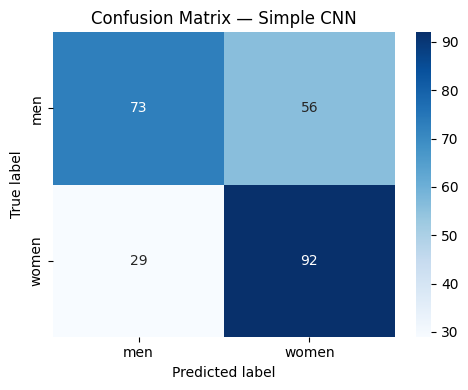

=== EfficientNet-B0 ===
Accuracy: 94.40% | Precision: 94.48% | Recall: 94.34% | F1: 94.39%
              precision    recall  f1-score   support

         men       0.93      0.96      0.95       129
       women       0.96      0.93      0.94       121

    accuracy                           0.94       250
   macro avg       0.94      0.94      0.94       250
weighted avg       0.94      0.94      0.94       250



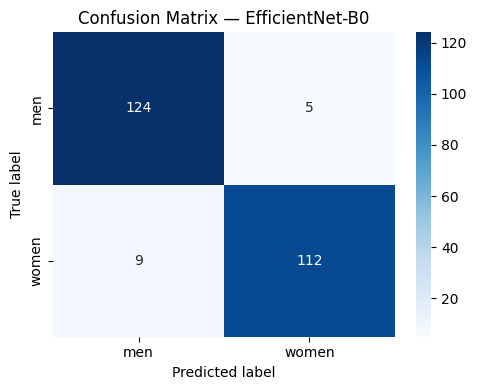

In [19]:
def evaluate_on_test(model, test_loader, class_names, model_name=""):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.max(1)[1].cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    print(f"=== {model_name} ===")
    print(f"Accuracy: {acc*100:.2f}% | Precision: {precision*100:.2f}% | "
          f"Recall: {recall*100:.2f}% | F1: {f1*100:.2f}%")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


class_names = base_dataset.classes
cnn_test_results = evaluate_on_test(cnn_model, test_loader, class_names, model_name="Simple CNN")
eff_test_results = evaluate_on_test(eff_model, test_loader, class_names, model_name="EfficientNet-B0")

In [20]:
comparison_df = pd.DataFrame({
    "Model": ["Simple CNN", "EfficientNet-B0"],
    "Accuracy (%)": [cnn_test_results["accuracy"]*100, eff_test_results["accuracy"]*100],
    "Precision (%)": [cnn_test_results["precision"]*100, eff_test_results["precision"]*100],
    "Recall (%)": [cnn_test_results["recall"]*100, eff_test_results["recall"]*100],
    "F1-score (%)": [cnn_test_results["f1"]*100, eff_test_results["f1"]*100],
}).round(2)

print(comparison_df.to_string(index=False))

          Model  Accuracy (%)  Precision (%)  Recall (%)  F1-score (%)
     Simple CNN          66.0          66.87       66.31         65.80
EfficientNet-B0          94.4          94.48       94.34         94.39


## Demo on new images

Upload a few photos (not from the dataset) to check how the trained models generalize.

In [21]:
from google.colab import files

uploaded = files.upload()
uploaded_paths = list(uploaded.keys())
print(f"Uploaded {len(uploaded_paths)} image(s): {uploaded_paths}")

Saving m2.jpg to m2 (1).jpg
Saving m1.jpg to m1 (1).jpg
Saving k2.jpg to k2 (1).jpg
Saving k1.jpg to k1 (1).jpg
Uploaded 4 image(s): ['m2 (1).jpg', 'm1 (1).jpg', 'k2 (1).jpg', 'k1 (1).jpg']


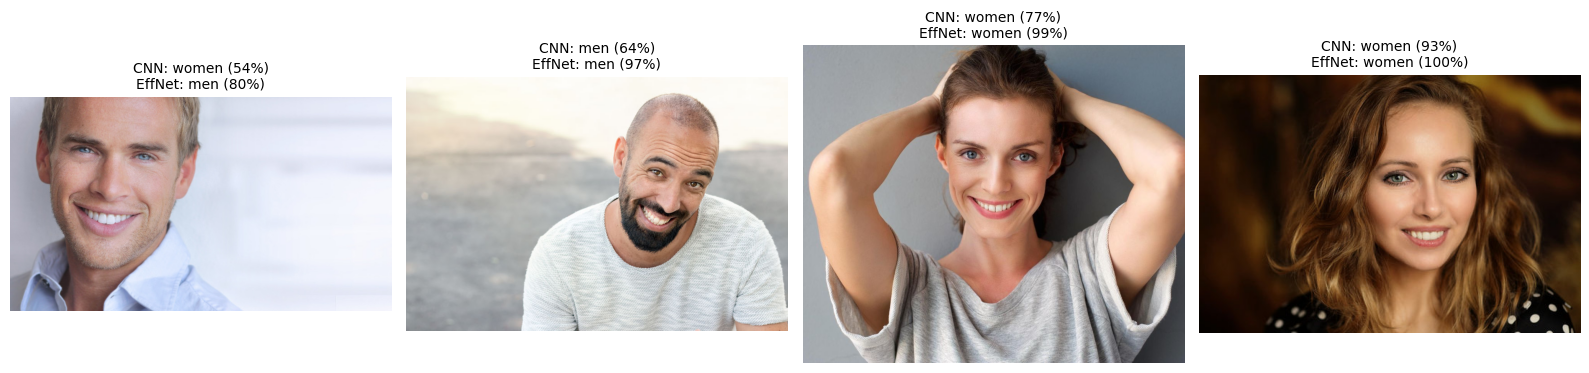

In [22]:
def predict_image(model, path, transform, class_names):
    img = Image.open(path).convert("RGB")
    x = transform(img).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(x), dim=1)[0]
    pred_idx = probs.argmax().item()
    return img, class_names[pred_idx], probs[pred_idx].item()


n = len(uploaded_paths)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]

for ax, path in zip(axes, uploaded_paths):
    img, cnn_pred, cnn_conf = predict_image(cnn_model, path, eval_transform, class_names)
    _, eff_pred, eff_conf = predict_image(eff_model, path, eval_transform, class_names)

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"CNN: {cnn_pred} ({cnn_conf*100:.0f}%)\n"
        f"EffNet: {eff_pred} ({eff_conf*100:.0f}%)",
        fontsize=10
    )

plt.tight_layout()
plt.show()

## Conclusions

- EfficientNet-B0 (transfer learning) achieves significantly higher test-set metrics than
SimpleCNN trained from scratch (94.4% vs 65.6% accuracy) - pretrained visual features from ImageNet provide a large advantage on a small custom dataset (1168 training images).

- SimpleCNN does not show strong overfitting (train and val accuracy stay close), but its
quality ceiling is low - 3 convolutional blocks from scratch are not enough to learn features that separate the classes well.

- The confusion matrix for both models shows no systematic bias toward one class - errors are
distributed across both classes.

- Data validation found 9 leakage cases (duplicate images split between train and val/test),
which were removed from train before training, making the test-set metrics reliable.

- On new, manually uploaded photos (outside the dataset), EfficientNet-B0 classified all examples correctly with high confidence (80-100%), while SimpleCNN made a wrong, low-confidence prediction on one image (54%) and was only marginally correct on another (64%). This matches the test-set results above and confirms that EfficientNet-B0 generalizes better to real-world images, not just to the held-out test split.